In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path("../scripts").resolve()))
import analisis_ttl as ttl


### Normalización de la señal

La normalización ocurre dentro de `ttl.process_sample()`, cuando se llama internamente a `ttl.Normalization()`. Antes de normalizar, el pipeline pasa los datos a formato largo, detecta la fase de temperatura (`heating`/`cooling`), opcionalmente filtra por fase con `phase_filter` y opcionalmente filtra por rango de temperatura con `temp_range`. Su objetivo es convertir la intensidad cruda de cada ROI (`IntDen`) en una señal comparable entre ROIs (`NormSignal`).

Orden actual del procesamiento:

1. Lectura de ABF y CSV de ROIs.
2. Detección de TTL y cálculo de temperatura promedio por TTL/frame.
3. Conversión del CSV de ImageJ a formato largo (`df_long`).
4. Detección de fase de temperatura (`df_long_phase`): `heating` si la temperatura sube y `cooling` si baja.
5. Filtro opcional por fase antes de normalizar (`df_for_norm`).
6. Filtro opcional por rango de temperatura antes de normalizar (`df_for_norm`).
7. Normalización de la señal sobre los datos incluidos en `df_for_norm`.

Esto significa que si `phase_filter="cooling"`, la normalización se calcula solo con puntos de cooling. En ese caso `I_baseline`, `Imax`, `T_at_Imax` y `NormSignal` describen el segmento cooling, no todo el registro.

Si `phase_filter=None`, la normalización usa heating + cooling juntos, como en el flujo anterior.

### Filtro por rango de temperatura (`temp_range`)

`Imax` se calcula como el máximo de `IntDen` dentro de `df_for_norm`. Si `temp_range=None`, ese máximo puede corresponder a una temperatura que después queda fuera de los `temp_ranges` usados en `analyze_temp_trends` (por ejemplo, un pico de cooling a 45°C cuando el análisis solo cubre 20-40°C). Eso infla o distorsiona `Imax` y, con `norm_type=1`, afecta `NormSignal` en todos los puntos.

Para evitarlo, `temp_range=(t_min, t_max)` filtra `df_for_norm` por `temp_mean` **antes** de normalizar, después de `phase_filter`. Así `I_baseline`, `Imax` y `T_at_Imax` quedan acotados al mismo rango de temperatura que se va a analizar.

`temp_range` debe cubrir `target_temp` (o `I_baseline` quedará sin datos) y, típicamente, el rango completo cubierto por `temp_ranges` (mínimo de la banda más fría, máximo de la banda más caliente). Con base en el análisis previo, la ventana térmica de trabajo actual es `temp_range=(20, 40)`, con `temp_ranges` distribuido dentro de ese rango.

Para cada ROI, el procedimiento es:

1. Se buscan los puntos cuya temperatura está cerca de una temperatura basal de referencia (`target_temp`).
2. Esa cercanía se define con una tolerancia (`tol`), que por defecto es ±0.5 °C.
3. Se calcula `I_baseline` como el promedio de `IntDen` dentro de ese rango de temperatura.
4. Se calcula `Imax` como la intensidad máxima observada para esa ROI en los datos incluidos.
5. Se registra `T_at_Imax`, que es la temperatura en la que ocurrió `Imax`.
6. Se calcula `NormSignal`, comparando cada punto contra `I_baseline`.

Variables que afectan la normalización:

- `target_temp`: temperatura usada como referencia basal. Por ejemplo, `target_temp=25` usa valores alrededor de 25 °C para calcular `I_baseline`.
- `tol`: ancho del rango alrededor de `target_temp`. Con `tol=0.5`, se usan valores entre `target_temp - 0.5` y `target_temp + 0.5`.
- `norm_type`: define la fórmula de normalización.
- `start_ttl`: afecta qué frame se asocia a cada TTL y, por lo tanto, qué temperatura se asigna a cada intensidad.
- `threshold`: afecta la detección de pulsos TTL y, por lo tanto, los eventos usados para calcular `temp_mean`.
- `drop_frames_without_ttl`: elimina frames que no tienen TTL asociado antes de normalizar.
- `phase_filter`: si es `"cooling"` o `"heating"`, filtra por fase antes de normalizar. Si es `None`, normaliza todos los puntos.
- `temp_range`: si es `(t_min, t_max)`, filtra por `temp_mean` antes de normalizar (después de `phase_filter`). Si es `None`, no se restringe por temperatura.

Fórmulas disponibles:

- `norm_type=1`: `NormSignal = (IntDen - I_baseline) / Imax`
- `norm_type=2`: `NormSignal = (IntDen - I_baseline) / I_baseline`

Tablas resultantes principales:

- `df_long`: datos en formato largo antes de clasificar fase.
- `df_long_phase`: datos en formato largo con columnas `dT` y `phase`.
- `df_for_norm`: datos usados realmente para calcular la normalización, después de aplicar `phase_filter` y `temp_range`.
- `df_norm` / `df_phase`: datos normalizados; conservan la columna `phase`.

Columnas resultantes principales:

- `I_baseline`: intensidad promedio de referencia para cada ROI.
- `Imax`: intensidad máxima observada para cada ROI, dentro de `phase_filter`/`temp_range`. No corresponde a una temperatura fija.
- `T_at_Imax`: temperatura en la que se observó `Imax`.
- `NormSignal`: señal normalizada usada para comparar respuestas entre ROIs y rangos de temperatura.


### Alineación frame-TTL y exclusión de segmentos

Cada TTL marca el inicio de un frame. Si la cámara comienza con el primer TTL generado durante la adquisición, la alineación correcta es `start_ttl = 0`:

- `frame 1 -> TTL 0`
- `frame 2 -> TTL 1`
- etc.

`start_ttl` debe usarse para corregir la alineación entre frames y TTL, no para eliminar segmentos iniciales. Si la cámara comenzó en TTL 0, cambiar `start_ttl` desplaza todos los frames y desalinearía imagen, temperatura y TTL.

Para excluir un tramo inicial sin perder la alineación, filtra después del procesamiento:

```python
df_phase_clean = df_phase[df_phase["TTL_index"] >= 11].copy()
```

Si necesitas analizar solo cooling después de ese corte:

```python
cooling_df_clean = df_phase_clean[df_phase_clean["phase"] == "cooling"].copy()
```

`cooling_df_clean` contiene solo puntos que pertenecen a la fase cooling y están dentro del rango de TTL que decidiste conservar.

Nota: `phase_filter` y `filter_analysis_window()` cumplen funciones distintas.

- `phase_filter` se aplica antes de normalizar y cambia los datos usados para calcular `I_baseline` e `Imax`.
- `filter_analysis_window()` se aplica después de normalizar y solo recorta qué tramo se analiza/grafica.

Si el objetivo es normalizar usando solo cooling, usa `phase_filter="cooling"`. Si el objetivo es eliminar un tramo temporal específico sin recalcular la normalización, usa `filter_analysis_window()`.


Archivos encontrados en: /Users/gfernandezv/Documents/envs/Images_TTL_temp/data/Proc_data/mut65_image19
  ROI CSV:
    - ROI_Results.csv
  ABF:
    - 26424028.abf
Procesamiento completo:
  eventos TTL: 65
  frames CSV total: 65
  frames con TTL asociado: 65
  frames sin TTL asociado: 0
  filtro de fase previo a normalizar: cooling
  filtro de rango de temperatura previo a normalizar: (20, 40)
  frames usados para normalizar: 44
  TTL_index asignados a frames: 0 a 64
  TTL_index detectados: 0 a 64
  filas df_norm: 4840
  ROIs: 110
  fases:
phase
cooling    44
Name: count, dtype: int64


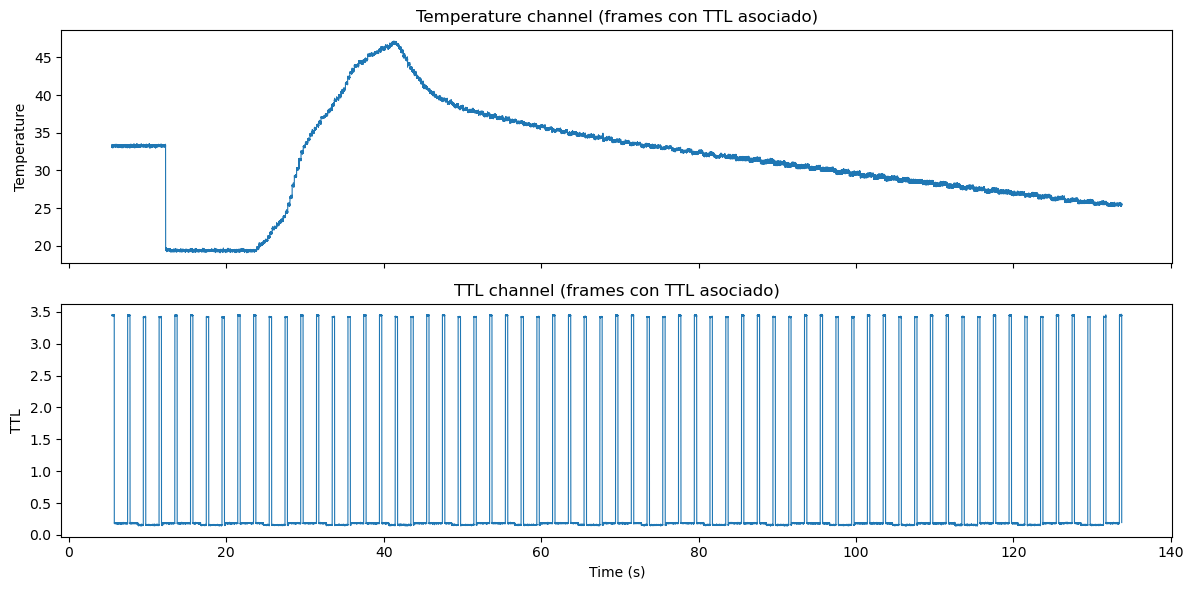

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Temperature channel (frames con TTL asociado)'}, ylabel='Temperature'>,
        <Axes: title={'center': 'TTL channel (frames con TTL asociado)'}, xlabel='Time (s)', ylabel='TTL'>],
       dtype=object))

In [3]:
input_dir = "/Users/gfernandezv/Documents/envs/Images_TTL_temp/data/Proc_data/mut65_image19"
sample = None
genotype = None

folder_name = Path(input_dir).name
if sample is None or genotype is None:
    parts = folder_name.split("_")
    if len(parts) == 2 and parts[0].startswith("mut") and parts[1].startswith("image"):
        inferred_genotype = "m" + parts[0][3:]
        inferred_sample = "sample_" + parts[1][5:]
    else:
        inferred_genotype = None
        inferred_sample = None

    sample = sample or inferred_sample
    genotype = genotype or inferred_genotype

start_ttl = 0
phase_filter = "cooling"  # opciones: None, "cooling", "heating"
temp_ranges={
        "low": (20, 27),
        "mid": (28, 33),
        "high": (34, 40),
    }
# Acota la normalización (I_baseline, Imax, T_at_Imax) a la ventana térmica
# de análisis (20-40°C), definida a partir del análisis previo, para que Imax
# no quede definido por puntos fuera de esa ventana. Debe cubrir target_temp
# y los temp_ranges de arriba.

temp_range = (20, 40)

processed = ttl.process_sample(
    input_dir,
    start_ttl=start_ttl,
    threshold=2.0,
    target_temp=25,
    norm_type=1,
    phase_filter=phase_filter,
    temp_range=temp_range,
)

files = processed["files"]
data = processed["data"]
df_norm = processed["df_norm"]
df_phase = processed["df_phase"]
heating_df = processed["heating_df"]
cooling_df = processed["cooling_df"]

ttl.plot_temp_ttl(
    data,
    temp_ttl_df=processed["temp_ttl_df"],
    frame_counts=processed["frame_counts"],
    only_used_frames=True,
)


### Ventana de análisis

Después de revisar la señal cruda y las ROIs pre-filtro, se puede elegir una ventana de análisis por `TTL_index` o por tiempo.

Esto permite excluir segmentos iniciales/finales o tramos inestables sin cambiar `start_ttl`, que debe mantenerse como parámetro de alineación frame-TTL.

Ejemplos:

```python
df_analysis = ttl.filter_analysis_window(df_phase, ttl_range=(11, 350))
df_analysis = ttl.filter_analysis_window(df_phase, time_range=(30, 700))
```

Los gráficos y el análisis de tendencias deben usar `df_analysis` cuando se quiera trabajar solo con esa ventana.


In [4]:
# Ajusta estos valores para elegir la ventana de análisis.
# Usa ttl_range=(inicio, fin) o time_range=(inicio_s, fin_s).
analysis_ttl_range = None
analysis_time_range = None #(20,120)

df_analysis = ttl.filter_analysis_window(
    df_phase,
    ttl_range=analysis_ttl_range,
    time_range=analysis_time_range,
)

Ventana de análisis: sin filtro
  frames únicos: 44
  TTL únicos: 44
  ROIs: 110
  fases:
phase
cooling    44
Name: count, dtype: int64


### Detección opcional de saltos/outliers

Algunas ROIs pueden tener saltos bruscos que se sobreponen con cambios reales de temperatura. Para detectarlos sin borrar datos, se puede calcular una tendencia local robusta por ROI y marcar puntos que se alejan demasiado de esa tendencia.

La detección agrega columnas como `local_trend`, `residual`, `robust_z` e `is_outlier`. Luego puedes decidir si analizar `df_analysis` completo o una versión sin outliers.


Outliers detectados: 5 / 4840 puntos
ROIs con al menos un outlier: 2


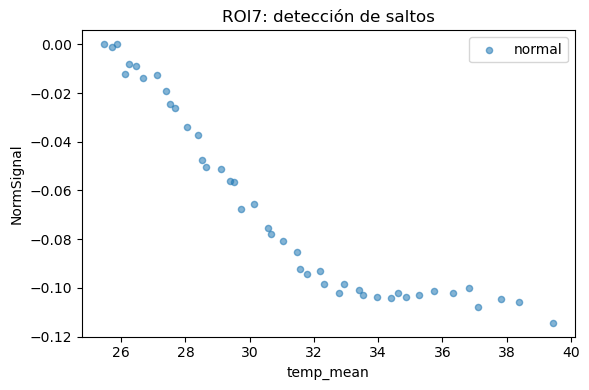

In [5]:
df_analysis_outliers = ttl.detect_roi_signal_outliers(
    df_analysis,
    value_col="NormSignal",
    window=11,
    z_thresh=4.0,
    min_abs_residual=0.05,
)

# Cambia el ROI para inspeccionar casos puntuales.
ttl.graph_roi_outlier_detection(
    df_analysis_outliers,
    roi="ROI7",
    value_col="NormSignal",
    x_col="temp_mean"
)

df_analysis_clean = df_analysis_outliers[~df_analysis_outliers["is_outlier"]].copy()

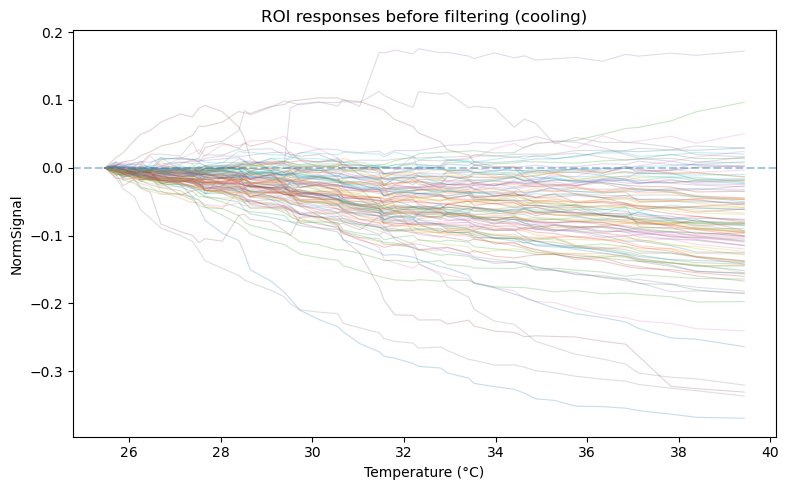

ROIs graficadas antes del filtro: 110
Filas graficadas: 4835


,frame,TTL_index,onset_idx,offset_idx,onset_time,offset_time,duration_s,temp_mean,temp_min,temp_max,...,dT,phase,NormSignal,I_baseline,Imax,T_at_Imax,local_trend,residual,robust_z,is_outlier
21,22,21,23725,23875,47.450,47.750,0.3,39.428105,39.123535,39.611816,...,-1.396735,cooling,-0.139435,224227.0,224227.0,25.474094,-0.133019,-0.006415,-2.641970,False
22,23,22,24725,24875,49.450,49.750,0.3,38.379998,38.055420,38.848877,...,-1.048107,cooling,-0.136460,224227.0,224227.0,25.474094,-0.130667,-0.005793,-2.385762,False
23,24,23,25724,25874,51.448,51.748,0.3,37.825629,37.628174,38.085938,...,-0.554369,cooling,-0.135372,224227.0,224227.0,25.474094,-0.128633,-0.006739,-2.775125,False
24,25,24,26724,26874,53.448,53.748,0.3,37.119076,36.865234,37.597656,...,-0.706553,cooling,-0.130667,224227.0,224227.0,25.474094,-0.126599,-0.004067,-1.674993,False
25,26,25,27724,27874,55.448,55.748,0.3,36.839971,36.590576,37.170410,...,-0.279104,cooling,-0.126599,224227.0,224227.0,25.474094,-0.123669,-0.002930,-1.206656,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,61,60,62724,62874,125.448,125.748,0.3,26.255627,26.031494,26.611328,...,-0.206347,cooling,-0.006354,12866.0,13062.0,26.693988,-0.000268,-0.006086,-1.510479,False
7146,62,61,63724,63874,127.448,127.748,0.3,26.113548,25.848389,26.367188,...,-0.142079,cooling,-0.011866,12866.0,13062.0,26.693988,-0.000536,-0.011331,-2.811961,False
7147,63,62,64724,64874,129.448,129.748,0.3,25.871428,25.604248,26.123047,...,-0.242120,cooling,-0.004823,12866.0,13062.0,26.693988,-0.001455,-0.003369,-0.835989,False
7148,64,63,65724,65874,131.448,131.748,0.3,25.703683,25.451660,25.939941,...,-0.167746,cooling,-0.000536,12866.0,13062.0,26.693988,-0.000536,0.000000,0.000000,False


In [7]:
ttl.graph_rois_before_filter(
    df_analysis_clean,
    phase="cooling",
    value_col="NormSignal"
)

### Respuesta por rango de temperatura

Resumen por tendencia:
trend
decrease    89
stable      11
increase    10
Name: count, dtype: int64
ROIs seleccionadas con tendencia increase: 10 / 110
ROIs seleccionadas con tendencia decrease: 89 / 110
ROIs seleccionadas con tendencia stable: 11 / 110
ROIs seleccionadas con tendencia insufficient: 0 / 110


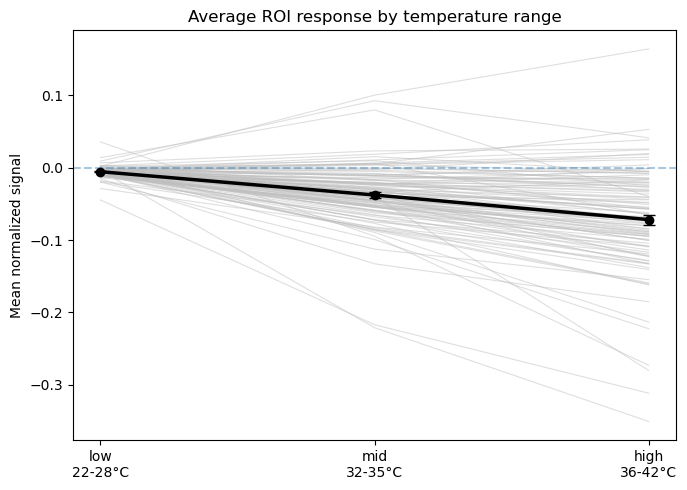

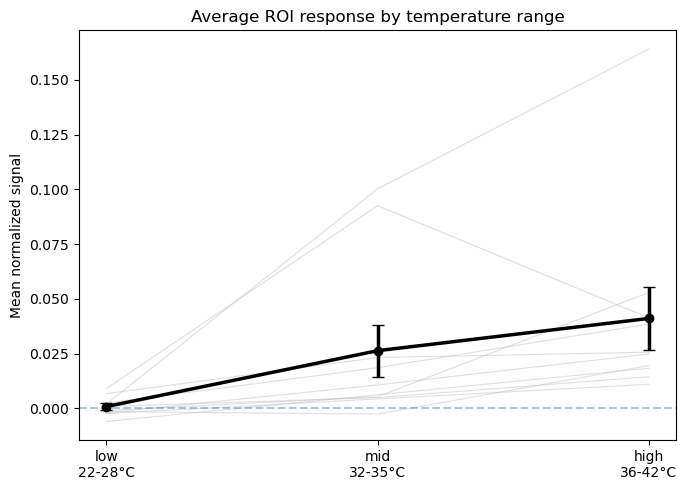

,range,mean,sem,n_rois
0,low,0.000861,0.001409,10
1,mid,0.026373,0.011917,10
2,high,0.041095,0.014284,10


In [9]:
trend_results = ttl.analyze_temp_trends(
    df_analysis_clean,
    phase="cooling",
    temp_ranges=temp_ranges,
    value_col="NormSignal",
    min_abs_delta=0.01,
    min_points=3,
)

roi_range_summary = trend_results["roi_summary"]
selected_increase = trend_results["selected_increase"]
selected_decrease = trend_results["selected_decrease"]
selected_stable = trend_results["selected_stable"]

ttl.graph_temp_range_summary(roi_range_summary)
ttl.graph_temp_range_summary(selected_increase)


### Inspeccion de datos

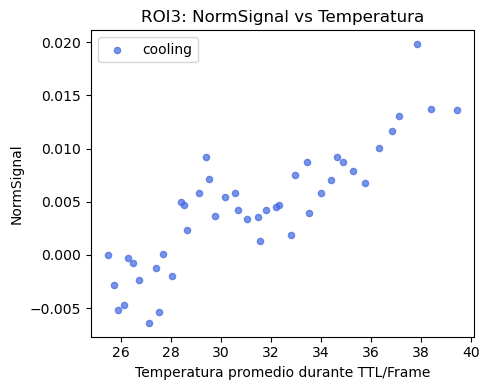

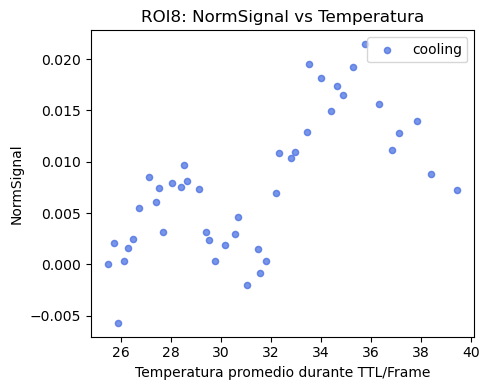

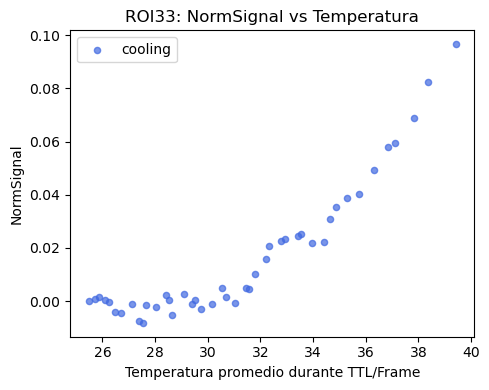

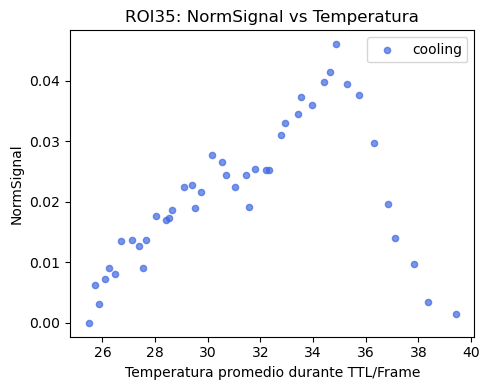

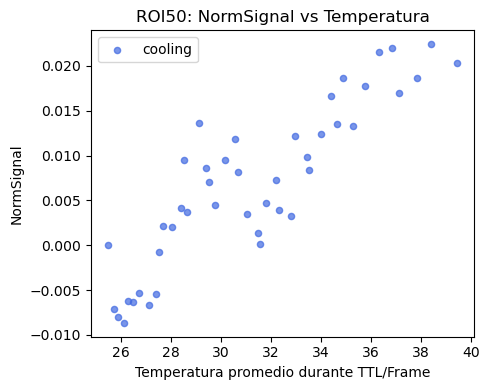

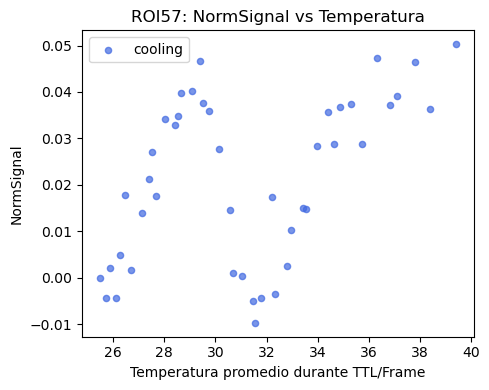

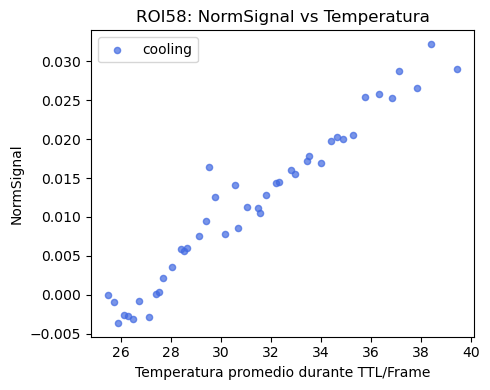

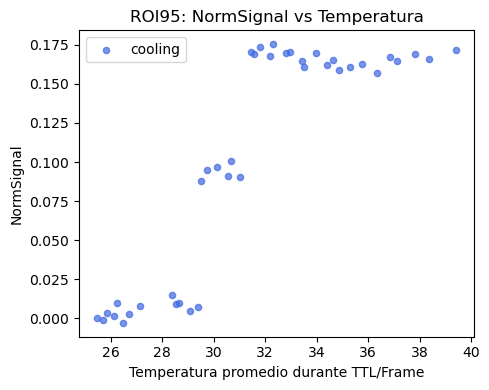

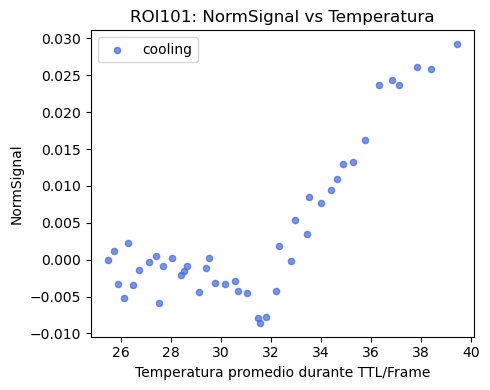

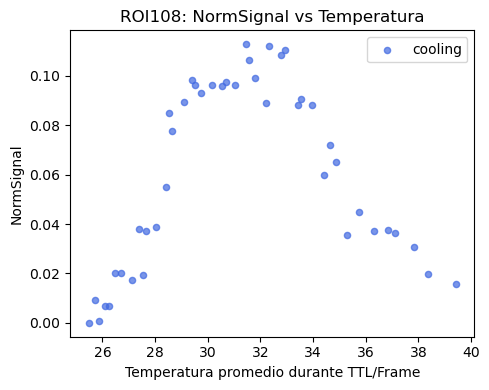

,frame,TTL_index,onset_idx,offset_idx,onset_time,offset_time,duration_s,temp_mean,temp_min,temp_max,...,dT,phase,NormSignal,I_baseline,Imax,T_at_Imax,local_trend,residual,robust_z,is_outlier
151,22,21,23725,23875,47.450,47.750,0.3,39.428105,39.123535,39.611816,...,-1.396735,cooling,0.013626,267033.0,272425.0,37.825629,0.013358,0.000268,0.143970,False
152,23,22,24725,24875,49.450,49.750,0.3,38.379998,38.055420,38.848877,...,-1.048107,cooling,0.013714,267033.0,272425.0,37.825629,0.013090,0.000624,0.335273,False
153,24,23,25724,25874,51.448,51.748,0.3,37.825629,37.628174,38.085938,...,-0.554369,cooling,0.019793,267033.0,272425.0,37.825629,0.012387,0.007406,3.978904,False
154,25,24,26724,26874,53.448,53.748,0.3,37.119076,36.865234,37.597656,...,-0.706553,cooling,0.013090,267033.0,272425.0,37.825629,0.011684,0.001406,0.755351,False
155,26,25,27724,27874,55.448,55.748,0.3,36.839971,36.590576,37.170410,...,-0.279104,cooling,0.011684,267033.0,272425.0,37.825629,0.010851,0.000833,0.447688,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7015,61,60,62724,62874,125.448,125.748,0.3,26.255627,26.031494,26.611328,...,-0.206347,cooling,0.006852,15408.0,17367.0,31.460591,0.013157,-0.006305,-0.978235,False
7016,62,61,63724,63874,127.448,127.748,0.3,26.113548,25.848389,26.367188,...,-0.142079,cooling,0.006679,15408.0,17367.0,31.460591,0.009040,-0.002361,-0.366280,False
7017,63,62,64724,64874,129.448,129.748,0.3,25.871428,25.604248,26.123047,...,-0.242120,cooling,0.000806,15408.0,17367.0,31.460591,0.007946,-0.007140,-1.107773,False
7018,64,63,65724,65874,131.448,131.748,0.3,25.703683,25.451660,25.939941,...,-0.167746,cooling,0.009040,15408.0,17367.0,31.460591,0.006852,0.002188,0.339479,False


In [10]:
ttl.graph_selected_rois_by_phase(
    df_analysis_clean,
    selected_increase,
    value_col="NormSignal"
)

### Inclusión manual de ROI tras inspección visual

Algunas ROI pueden verse claramente válidas tras la inspección visual de los gráficos (por ejemplo porque siguen una respuesta consistente y limpia). En lugar de marcar ROI inválidas, aquí marcamos las ROI que queremos conservar como válidas (`ROI_status=1`) y dejamos el resto como inválidas (`ROI_status=0`).

Se aplica sobre `df_phase`, porque es la tabla que se exporta como `*_preprocessed_long.csv` más abajo, y así ese archivo queda con el estatus real después de todos los filtros (automáticos + inspección visual).

In [ ]:
# Lista las ROI que se ven válidas en la inspección visual anterior.
# scoped_roi_valid permite marcar una ROI como válida solo para esta muestra si el
# CSV final combina varias, ej. [{"sample": sample, "ROI": "ROI7"}].
roi_valid_manual = []  # ejemplo: ["ROI7", "ROI12"]
scoped_roi_valid = None

# Todas las ROIs parten como invalidas (ROI_status=0) y las especificadas se
# marcan como validas (ROI_status=1).
df_phase = ttl.mark_roi_status(
    df_phase,
    roi_exclude=roi_valid_manual,
    scoped_exclude=scoped_roi_valid,
    default_status=0,
    excluded_status=1,
    preserve_existing=False,
)


### Archivos exportados: processed vs filtered

`processed.csv` y `filtered.csv` tienen la misma estructura de columnas, pero no las mismas filas.

- `processed.csv`: contiene todas las ROI disponibles después de aplicar `phase_filter` y normalizar.
- `filtered.csv`: contiene un subconjunto de `processed.csv`, limitado a las ROI seleccionadas en `selected` al llamar `ttl.export_results()`.

Con el flujo actual, si `phase_filter="cooling"`:

- `processed.csv` = todas las ROI durante cooling, normalizadas usando solo cooling.
- `filtered.csv` = solo las ROI seleccionadas, por ejemplo `selected_increase`, durante cooling.

Si se exporta con `roi_summary=roi_range_summary`, ambos archivos incluyen la clasificación de comportamiento por ROI en la columna `trend` (`increase`, `decrease`, `stable` o `insufficient`).

### CSV preprocesado para análisis batch

Además de `processed.csv` y `filtered.csv`, el pipeline puede exportar un archivo largo enriquecido:

- `*_preprocessed_long.csv`: una fila por ROI/frame/TTL, con `phase`, `trend`, métricas por rango de temperatura y `ROI_status`. `ROI_status` conserva lo que ya traiga `df_phase` (por ejemplo las marcas de la celda de exclusión manual de arriba) y solo usa 1 como valor por defecto donde no había nada.

Este archivo representa el preprocesamiento recomendado para análisis grupales: conserva el universo de datos en formato largo y deja las decisiones manuales de inclusión/exclusión para `ROI_status`.


In [ ]:
preprocessed = ttl.export_preprocessed_long(
    df_phase,
    sample=sample,
    genotype=genotype,
    output_dir=files["output_dir"],
    phase=phase_filter,
    temp_ranges=temp_ranges,
    value_col="NormSignal",
    min_abs_delta=0.01,
    min_points=3,
    roi_summary=roi_range_summary,
    norm_temp_range=temp_range,
)
